In [98]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. LOAD DATA
df = pd.read_csv("medical_insurance.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# 3. BASIC DATA ANALYSIS
print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes.value_counts())

# 4. PREPROCESSING - HANDLE MISSING VALUES
print("\nnote: Outcome from previous commit gave missing values in dataset analysis. Handling missing values in the next step before encoding categorical features.")

# Check alcohol_freq values before fixing
print("\nAlcohol frequency before handling:")
print(df['alcohol_freq'].value_counts(dropna=False))

# Fill NaN with 'Unknown' as a valid category
df['alcohol_freq'] = df['alcohol_freq'].fillna('Unknown')

print("\nAlcohol frequency after handling:")
print(df['alcohol_freq'].value_counts())

# Verify no missing values remain
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

# 5. DROP UNNECESSARY FEATURES
columns_to_drop = [
    "person_id",
    "policy_term_years",
    "policy_changes_last_2yrs",
    "provider_quality",
    "risk_score",
    # "annual_premium",
    # "monthly_premium",
    # "claims_count",
    # "avg_claim_amount",
    # "total_claims_paid"
]

df = df.drop(columns=columns_to_drop)

print("\nRemaining Features:", df.shape[1])

# 6. ENCODING CATEGORICAL DATA
categorical_cols = df.select_dtypes(include=["object"]).columns
print(f"\nCategorical columns to encode: {categorical_cols.tolist()}")

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

# 7. DEFINE FEATURES & TARGET
X = df.drop("annual_medical_cost", axis=1)
y = df["annual_medical_cost"]

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# 8. DATA SPLITTING (70 / 10 / 20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42
)

print("\nData split completed.")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Dataset Shape: (100000, 54)

First 5 rows:
   person_id  age     sex   region urban_rural  income     education  \
0      75722   52  Female    North    Suburban   22700     Doctorate   
1      80185   79  Female    North       Urban   12800         No HS   
2      19865   68    Male    North       Rural   40700            HS   
3      76700   15    Male    North    Suburban   15600  Some College   
4      92992   53    Male  Central    Suburban   89600     Doctorate   

  marital_status employment_status  household_size  ...  liver_disease  \
0        Married           Retired               3  ...              0   
1        Married          Employed               3  ...              0   
2        Married           Retired               5  ...              0   
3        Married     Self-employed               5  ...              0   
4        Married     Self-employed               2  ...              0   

   arthritis mental_health proc_imaging_count  proc_surgery_count  \
0         

In [99]:
# 9. SETTING HYPERPARAMETERS
hyperparams = {
    'n_estimators': 200,      # Number of boosting stages
    'learning_rate': 0.05,     # Shrinks contribution of each tree
    'max_depth': 4,           # Maximum depth of individual trees
    'min_samples_split': 10,   # Minimum samples required to split node
    'min_samples_leaf': 5,    # Minimum samples required at leaf node
    'subsample': 0.8,         # Fraction of samples used for fitting trees
    'max_features': 'sqrt',     # Feature subsampling
    'random_state': 42        # For reproducibility
}

# 10. MODEL TRAINING
print("\nModel training started!")

# Create lists to store training progress
train_scores = []
val_scores = []
n_estimators_list = []


# Get base model
model = GradientBoostingRegressor(**hyperparams, warm_start=True)

# Train incrementally to track performance
n_estimators_list = []
train_mae_list = []
val_mae_list = []
train_rmse_list = []
val_rmse_list = []
train_r2_list = []
val_r2_list = []

print("Training trees incrementally...")

# Train incrementally to track performance
for i in range(1, hyperparams['n_estimators'] + 1):
    model.set_params(n_estimators=i)
    model.fit(X_train, y_train)
    
    # Record progress every 20 trees to avoid too much output
    if i % 10 == 0 or i == 1 or i == hyperparams['n_estimators']:
        # Training predictions and metrics
        train_pred = model.predict(X_train)
        train_mae = mean_absolute_error(y_train, train_pred)
        train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
        train_r2 = r2_score(y_train, train_pred)
        
        # Validation predictions and metrics
        val_pred = model.predict(X_val)
        val_mae = mean_absolute_error(y_val, val_pred)
        val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
        val_r2 = r2_score(y_val, val_pred)
        
        # Store metrics
        n_estimators_list.append(i)
        train_mae_list.append(train_mae)
        val_mae_list.append(val_mae)
        train_rmse_list.append(train_rmse)
        val_rmse_list.append(val_rmse)
        train_r2_list.append(train_r2)
        val_r2_list.append(val_r2)
        
        print(f"Trees: {i:4d}/{hyperparams['n_estimators']} | "
              f"Train MAE: ${train_mae:,.2f} | Val MAE: ${val_mae:,.2f} | "
              f"Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f}")

print("\nModel training completed!")


Model training started!
Training trees incrementally...
Trees:    1/200 | Train MAE: $1,915.46 | Val MAE: $1,881.80 | Train R²: 0.0807 | Val R²: 0.0795
Trees:   10/200 | Train MAE: $1,500.71 | Val MAE: $1,474.54 | Train R²: 0.4130 | Val R²: 0.4235
Trees:   20/200 | Train MAE: $1,150.44 | Val MAE: $1,128.26 | Train R²: 0.6363 | Val R²: 0.6539
Trees:   30/200 | Train MAE: $898.96 | Val MAE: $881.97 | Train R²: 0.7675 | Val R²: 0.7854
Trees:   40/200 | Train MAE: $733.73 | Val MAE: $722.60 | Train R²: 0.8451 | Val R²: 0.8579
Trees:   50/200 | Train MAE: $635.49 | Val MAE: $628.65 | Train R²: 0.8838 | Val R²: 0.8930
Trees:   60/200 | Train MAE: $551.53 | Val MAE: $548.75 | Train R²: 0.9126 | Val R²: 0.9183
Trees:   70/200 | Train MAE: $494.63 | Val MAE: $494.47 | Train R²: 0.9306 | Val R²: 0.9337
Trees:   80/200 | Train MAE: $469.35 | Val MAE: $470.47 | Train R²: 0.9365 | Val R²: 0.9389
Trees:   90/200 | Train MAE: $439.89 | Val MAE: $442.60 | Train R²: 0.9459 | Val R²: 0.9459
Trees:  100

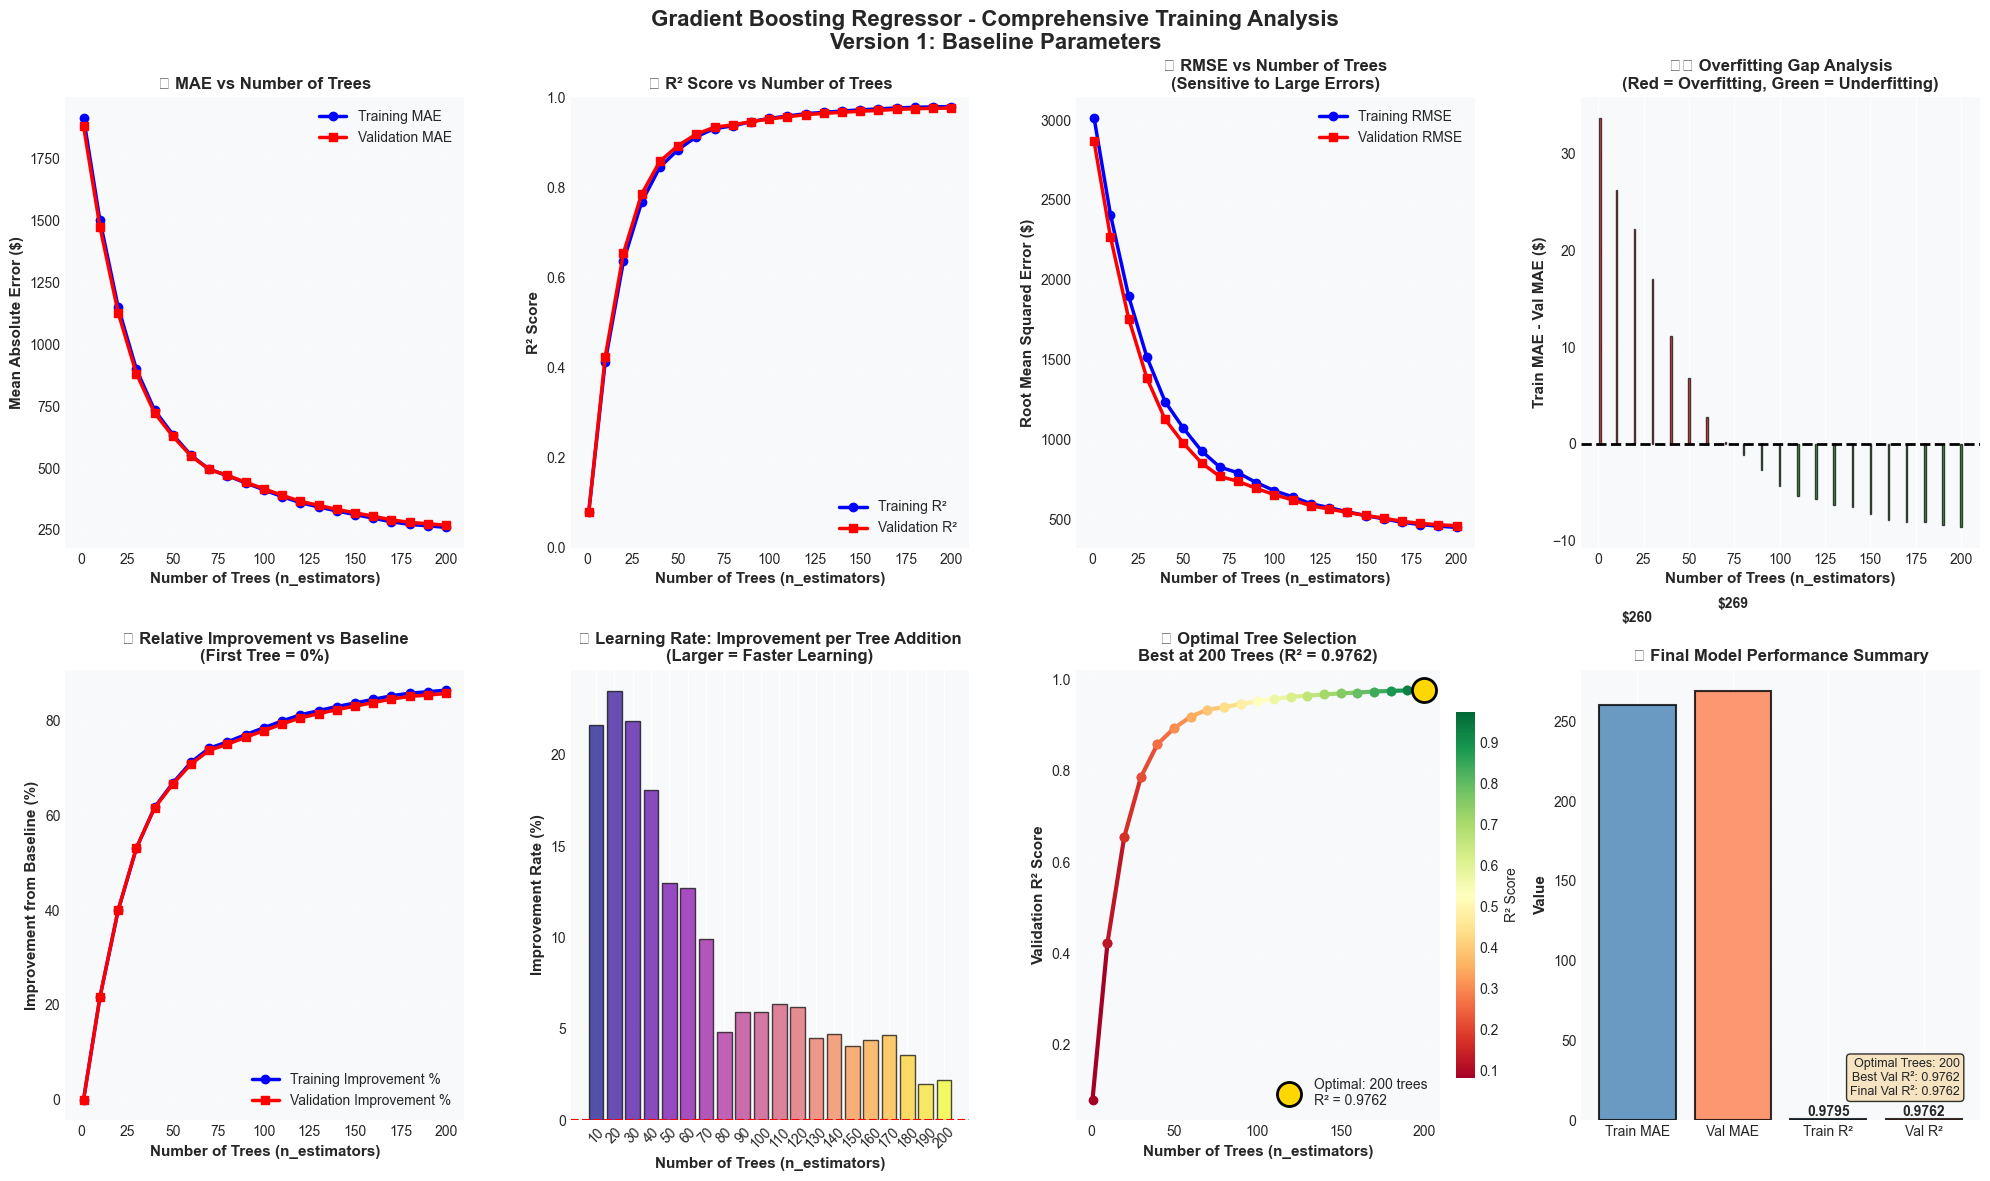


Training summary statistics:

👾 Optimal Number of Trees: 200
   Best Validation R² Score: 0.9762
   Best Validation MAE: $268.87

👾 Final Model Performance (200 trees):
   Training MAE: $260.27
   Validation MAE: $268.87
   Training R²: 0.9795
   Validation R²: 0.9762

👾 Overfitting Assessment:
   Gap: $-8.60 - ✅ Good generalization

👾 Learning Progress:
   MAE Reduction: $1,655.19 (Training)
   MAE Reduction: $1,612.93 (Validation)
   R² Improvement: 0.8988 (Training)
   R² Improvement: 0.8967 (Validation)


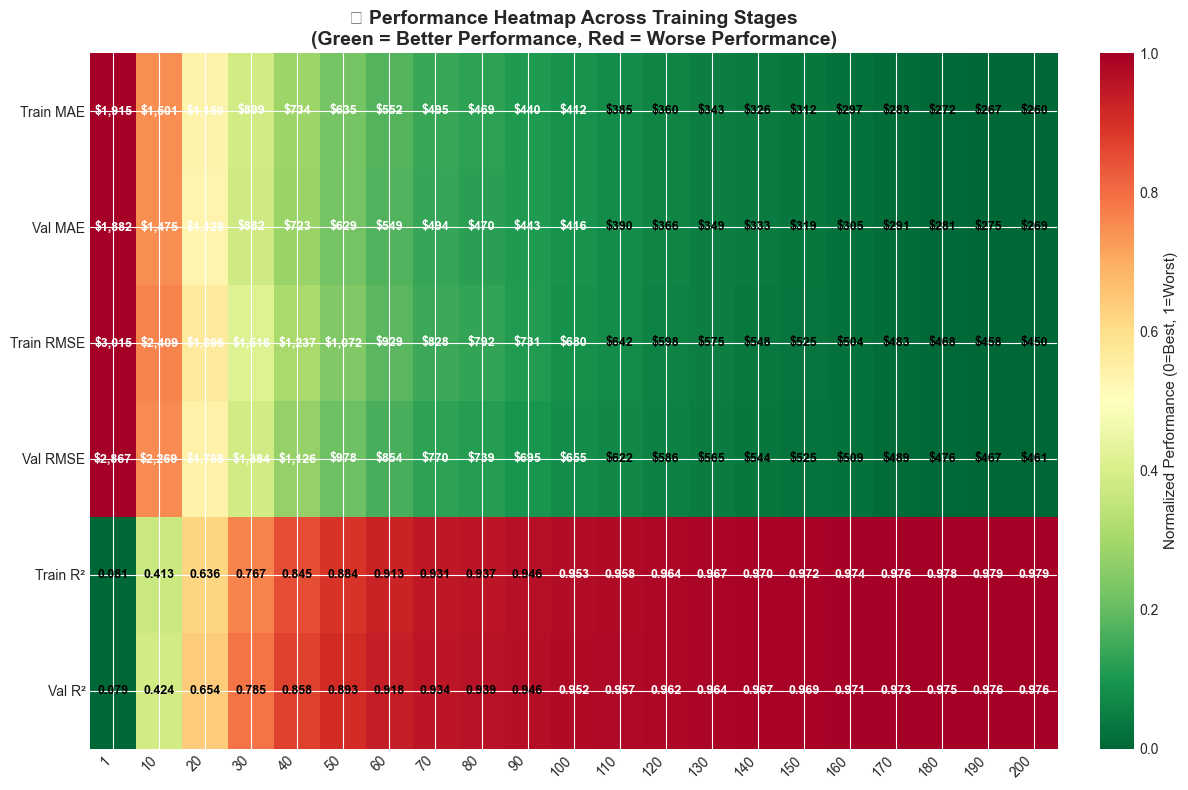

✅ Model saved as: gradient_boosting_final_model.pkl
✅ Label encoders saved as: label_encoders.pkl


In [100]:
# 11. CREATE TRAINING PROGRESS VISUALIZATIONS 
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (18, 12)
plt.rcParams['font.size'] = 10

# Create a comprehensive figure with 2x4 subplots for 8 visualizations
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
fig.suptitle(f'Gradient Boosting Regressor - Comprehensive Training Analysis\nVersion 1: Baseline Parameters', 
             fontsize=16, fontweight='bold', y=0.98)

# PLOT 1: MAE vs Number of Trees
ax1 = axes[0, 0]
ax1.plot(n_estimators_list, train_mae_list, 'b-', linewidth=2.5, label='Training MAE', marker='o', markersize=6)
ax1.plot(n_estimators_list, val_mae_list, 'r-', linewidth=2.5, label='Validation MAE', marker='s', markersize=6)
ax1.fill_between(n_estimators_list, train_mae_list, val_mae_list, alpha=0.2, color='purple')
ax1.set_xlabel('Number of Trees (n_estimators)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Mean Absolute Error ($)', fontsize=11, fontweight='bold')
ax1.set_title('📊 MAE vs Number of Trees', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#f8f9fa')

# PLOT 2: R² Score vs Number of Trees
ax2 = axes[0, 1]
ax2.plot(n_estimators_list, train_r2_list, 'b-', linewidth=2.5, label='Training R²', marker='o', markersize=6)
ax2.plot(n_estimators_list, val_r2_list, 'r-', linewidth=2.5, label='Validation R²', marker='s', markersize=6)
ax2.fill_between(n_estimators_list, train_r2_list, val_r2_list, alpha=0.2, color='orange')
ax2.set_xlabel('Number of Trees (n_estimators)', fontsize=11, fontweight='bold')
ax2.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax2.set_title('🎯 R² Score vs Number of Trees', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)
ax2.set_facecolor('#f8f9fa')

# PLOT 3: RMSE vs Number of Trees
ax3 = axes[0, 2]
ax3.plot(n_estimators_list, train_rmse_list, 'b-', linewidth=2.5, label='Training RMSE', marker='o', markersize=6)
ax3.plot(n_estimators_list, val_rmse_list, 'r-', linewidth=2.5, label='Validation RMSE', marker='s', markersize=6)
ax3.set_xlabel('Number of Trees (n_estimators)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Root Mean Squared Error ($)', fontsize=11, fontweight='bold')
ax3.set_title('📈 RMSE vs Number of Trees\n(Sensitive to Large Errors)', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_facecolor('#f8f9fa')

# PLOT 4: Overfitting Gap Analysis (MAE Difference)
ax4 = axes[0, 3]
overfitting_gap = [t - v for t, v in zip(train_mae_list, val_mae_list)]
colors_gap = ['red' if gap > 0 else 'green' for gap in overfitting_gap]
bars = ax4.bar(n_estimators_list, overfitting_gap, color=colors_gap, alpha=0.7, edgecolor='black', linewidth=1)
ax4.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax4.set_xlabel('Number of Trees (n_estimators)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Train MAE - Val MAE ($)', fontsize=11, fontweight='bold')
ax4.set_title('⚠️ Overfitting Gap Analysis\n(Red = Overfitting, Green = Underfitting)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_facecolor('#f8f9fa')

# PLOT 5: Relative Improvement from Baseline
ax5 = axes[1, 0]
train_improvement = [100 * (train_mae_list[0] - e) / train_mae_list[0] for e in train_mae_list]
val_improvement = [100 * (val_mae_list[0] - e) / val_mae_list[0] for e in val_mae_list]

ax5.plot(n_estimators_list, train_improvement, 'b-', linewidth=2.5, label='Training Improvement %', marker='o', markersize=6)
ax5.plot(n_estimators_list, val_improvement, 'r-', linewidth=2.5, label='Validation Improvement %', marker='s', markersize=6)
ax5.fill_between(n_estimators_list, train_improvement, val_improvement, alpha=0.2, color='teal')
ax5.set_xlabel('Number of Trees (n_estimators)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Improvement from Baseline (%)', fontsize=11, fontweight='bold')
ax5.set_title('📉 Relative Improvement vs Baseline\n(First Tree = 0%)', fontsize=12, fontweight='bold')
ax5.legend(loc='lower right', fontsize=10)
ax5.grid(True, alpha=0.3)
ax5.set_facecolor('#f8f9fa')

# PLOT 6: Learning Rate (Improvement per Tree Addition)
ax6 = axes[1, 1]
val_improvement_rate = []
for i in range(1, len(val_mae_list)):
    rate = (val_mae_list[i-1] - val_mae_list[i]) / val_mae_list[i-1] * 100
    val_improvement_rate.append(rate)

n_estimators_rate = n_estimators_list[1:]

# Color gradient based on improvement rate
colors_rate = plt.cm.plasma(np.linspace(0, 1, len(val_improvement_rate)))
bars_rate = ax6.bar(range(len(n_estimators_rate)), val_improvement_rate, color=colors_rate, alpha=0.7, edgecolor='black')
ax6.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax6.set_xticks(range(len(n_estimators_rate)))
ax6.set_xticklabels(n_estimators_rate, rotation=45)
ax6.set_xlabel('Number of Trees (n_estimators)', fontsize=11, fontweight='bold')
ax6.set_ylabel('Improvement Rate (%)', fontsize=11, fontweight='bold')
ax6.set_title('⚡ Learning Rate: Improvement per Tree Addition\n(Larger = Faster Learning)', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')
ax6.set_facecolor('#f8f9fa')

# PLOT 7: Optimal Tree Selection with Gradient Colors
ax7 = axes[1, 2]

# Find best validation R²
best_idx = val_r2_list.index(max(val_r2_list))
best_trees = n_estimators_list[best_idx]
best_r2 = val_r2_list[best_idx]

# Create gradient color line
colors_line = plt.cm.RdYlGn(np.linspace(0, 1, len(n_estimators_list)))

for i in range(len(n_estimators_list) - 1):
    ax7.plot(n_estimators_list[i:i+2], val_r2_list[i:i+2], 
            color=colors_line[i], linewidth=3, marker='o', markersize=6)

# Highlight best point
ax7.scatter(best_trees, best_r2, color='gold', s=300, edgecolor='black', 
           zorder=5, linewidth=2, label=f'Optimal: {best_trees} trees\nR² = {best_r2:.4f}')

ax7.set_xlabel('Number of Trees (n_estimators)', fontsize=11, fontweight='bold')
ax7.set_ylabel('Validation R² Score', fontsize=11, fontweight='bold')
ax7.set_title(f'🎯 Optimal Tree Selection\nBest at {best_trees} Trees (R² = {best_r2:.4f})', 
             fontsize=12, fontweight='bold')
ax7.grid(True, alpha=0.3)
ax7.legend(loc='lower right', fontsize=10)
ax7.set_facecolor('#f8f9fa')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=min(val_r2_list), vmax=max(val_r2_list)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax7, fraction=0.046, pad=0.04)
cbar.set_label('R² Score', fontsize=10)

# PLOT 8: Performance Summary Dashboard
ax8 = axes[1, 3]

# Create summary metrics
final_train_mae = train_mae_list[-1]
final_val_mae = val_mae_list[-1]
final_train_r2 = train_r2_list[-1]
final_val_r2 = val_r2_list[-1]

# Create bar chart for final performance
metrics = ['Train MAE', 'Val MAE', 'Train R²', 'Val R²']
values = [final_train_mae, final_val_mae, final_train_r2, final_val_r2]
colors_metrics = ['steelblue', 'coral', 'steelblue', 'coral']

bars_metrics = ax8.bar(metrics, values, color=colors_metrics, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, val in zip(bars_metrics, values):
    if val < 1:  # For R² scores
        ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    else:  # For MAE values
        ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax8.set_ylabel('Value', fontsize=11, fontweight='bold')
ax8.set_title('📊 Final Model Performance Summary', fontsize=12, fontweight='bold')
ax8.set_facecolor('#f8f9fa')
ax8.grid(True, alpha=0.3, axis='y')

# Add a text box with optimal tree information
textstr = f'Optimal Trees: {best_trees}\nBest Val R²: {best_r2:.4f}\nFinal Val R²: {final_val_r2:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax8.text(0.95, 0.05, textstr, transform=ax8.transAxes, fontsize=9,
        verticalalignment='bottom', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig('gradient_boosting_comprehensive_training.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTraining summary statistics:")

print(f"\n👾 Optimal Number of Trees: {best_trees}")
print(f"   Best Validation R² Score: {best_r2:.4f}")
print(f"   Best Validation MAE: ${val_mae_list[best_idx]:,.2f}")

print(f"\n👾 Final Model Performance ({hyperparams['n_estimators']} trees):")
print(f"   Training MAE: ${train_mae_list[-1]:,.2f}")
print(f"   Validation MAE: ${val_mae_list[-1]:,.2f}")
print(f"   Training R²: {train_r2_list[-1]:.4f}")
print(f"   Validation R²: {val_r2_list[-1]:.4f}")

print(f"\n👾 Overfitting Assessment:")
gap_final = train_mae_list[-1] - val_mae_list[-1]
if gap_final > 100:
    print(f"   Gap: ${gap_final:,.2f} - ⚠️ Potential overfitting detected")
elif gap_final < -100:
    print(f"   Gap: ${gap_final:,.2f} - 📉 Model may be underfitting")
else:
    print(f"   Gap: ${gap_final:,.2f} - ✅ Good generalization")

print(f"\n👾 Learning Progress:")
print(f"   MAE Reduction: ${train_mae_list[0] - train_mae_list[-1]:,.2f} (Training)")
print(f"   MAE Reduction: ${val_mae_list[0] - val_mae_list[-1]:,.2f} (Validation)")
print(f"   R² Improvement: {train_r2_list[-1] - train_r2_list[0]:.4f} (Training)")
print(f"   R² Improvement: {val_r2_list[-1] - val_r2_list[0]:.4f} (Validation)")

# Create a performance heatmap to visualize all metrics across training stages
fig2, ax_heat = plt.subplots(1, 1, figsize=(12, 8))

# Create performance matrix for heatmap
performance_data = {
    'Trees': n_estimators_list,
    'Train MAE': train_mae_list,
    'Val MAE': val_mae_list,
    'Train RMSE': train_rmse_list,
    'Val RMSE': val_rmse_list,
    'Train R²': train_r2_list,
    'Val R²': val_r2_list
}

df_performance = pd.DataFrame(performance_data)

# Create normalized heatmap data
heatmap_data = df_performance.set_index('Trees').T
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
heatmap_normalized = pd.DataFrame(scaler.fit_transform(heatmap_data.T).T, 
                                   index=heatmap_data.index, 
                                   columns=heatmap_data.columns)

im = ax_heat.imshow(heatmap_normalized, cmap='RdYlGn_r', aspect='auto', interpolation='nearest')
ax_heat.set_xticks(range(len(heatmap_normalized.columns)))
ax_heat.set_xticklabels(heatmap_normalized.columns, rotation=45, ha='right')
ax_heat.set_yticks(range(len(heatmap_normalized.index)))
ax_heat.set_yticklabels(heatmap_normalized.index)
ax_heat.set_title('🔥 Performance Heatmap Across Training Stages\n(Green = Better Performance, Red = Worse Performance)', 
             fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04)
cbar.set_label('Normalized Performance (0=Best, 1=Worst)', fontsize=11)

# Add text annotations with actual values
for i in range(len(heatmap_normalized.index)):
    for j in range(len(heatmap_normalized.columns)):
        value = heatmap_data.iloc[i, j]
        if 'MAE' in heatmap_normalized.index[i] or 'RMSE' in heatmap_normalized.index[i]:
            text = f'${value:,.0f}'
        else:
            text = f'{value:.3f}'
        ax_heat.text(j, i, text, ha="center", va="center", 
                    color="black" if value < heatmap_data.iloc[i].median() else "white",
                    fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('performance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 12. SAVE THE MODEL AND ENCODERS
# Retrain with optimal number of trees on full training data
final_model = GradientBoostingRegressor(
    n_estimators=best_trees,  # Use optimal trees from validation
    learning_rate=hyperparams['learning_rate'],
    max_depth=hyperparams['max_depth'],
    min_samples_split=hyperparams['min_samples_split'],
    min_samples_leaf=hyperparams['min_samples_leaf'],
    subsample=hyperparams['subsample'],
    random_state=42
)

# Train on full training set (no validation split for final model)
final_model.fit(X_train, y_train)

# Save model and encoders
joblib.dump(final_model, 'gradient_boosting_final_model.pkl')
joblib.dump(encoders, 'label_encoders.pkl')

print("✅ Model saved as: gradient_boosting_final_model.pkl")
print("✅ Label encoders saved as: label_encoders.pkl")


📊 TOP 20 MOST IMPORTANT FEATURES:
--------------------------------------------------
26. annual_premium                 : 0.6650 (66.50%)
27. monthly_premium                : 0.2726 (27.26%)
23. network_tier                   : 0.0561 (5.61%)
30. total_claims_paid              : 0.0052 (0.52%)
24. deductible                     : 0.0006 (0.06%)
20. ldl                            : 0.0001 (0.01%)
 5. income                         : 0.0001 (0.01%)
29. avg_claim_amount               : 0.0000 (0.00%)
18. systolic_bp                    : 0.0000 (0.00%)
 4. urban_rural                    : 0.0000 (0.00%)
 1. age                            : 0.0000 (0.00%)
28. claims_count                   : 0.0000 (0.00%)
42. proc_imaging_count             : 0.0000 (0.00%)
14. visits_last_year               : 0.0000 (0.00%)
 6. education                      : 0.0000 (0.00%)
11. bmi                            : 0.0000 (0.00%)
 7. marital_status                 : 0.0000 (0.00%)
12. smoker                  

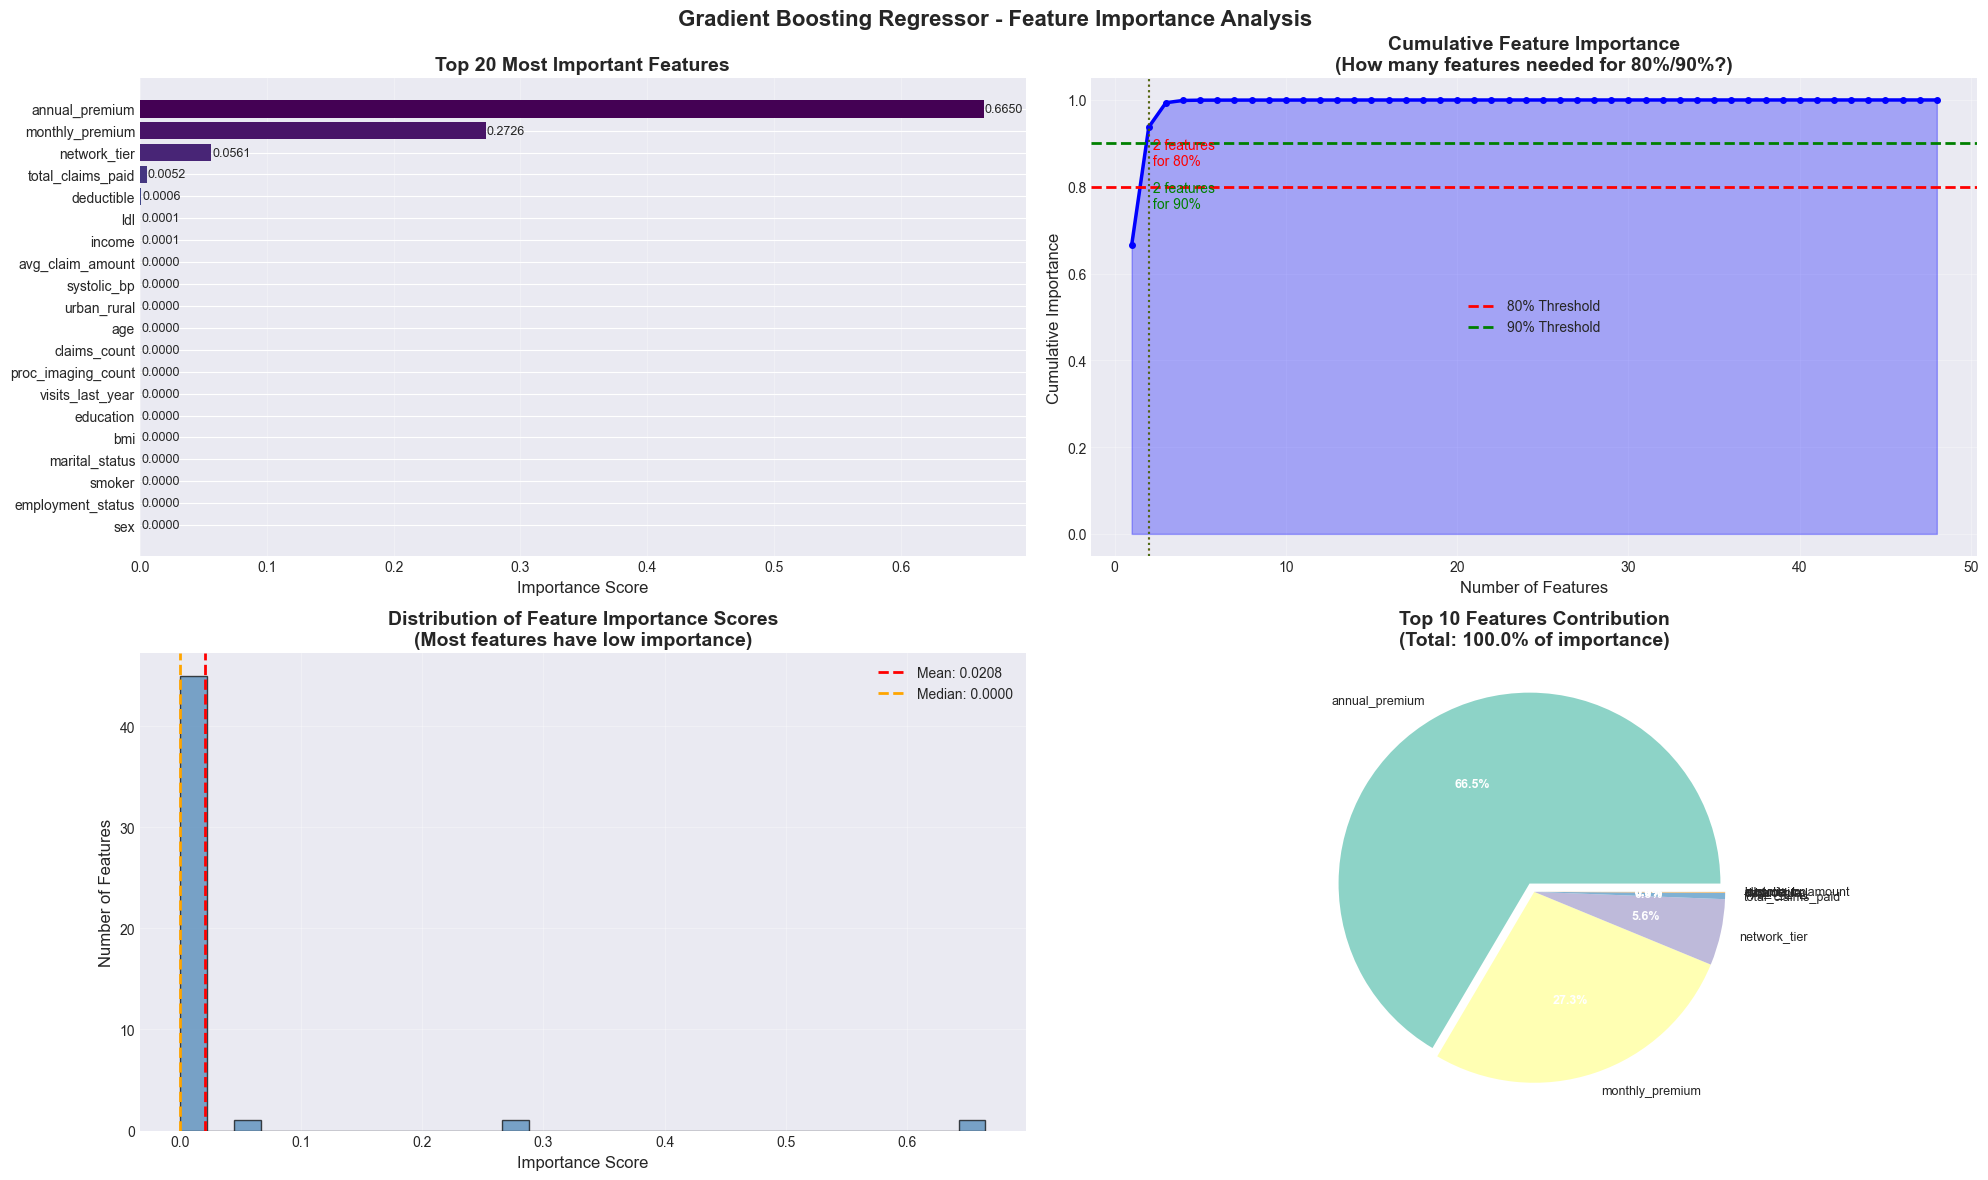


📊 TOP 15 FEATURES BY CORRELATION WITH MEDICAL COST:
------------------------------------------------------------
annual_premium                 :  0.9656 (Positive, Strong)
monthly_premium                :  0.9656 (Positive, Strong)
total_claims_paid              :  0.7467 (Positive, Strong)
avg_claim_amount               :  0.6386 (Positive, Strong)
chronic_count                  :  0.2955 (Positive, Weak)
is_high_risk                   :  0.2517 (Positive, Weak)
days_hospitalized_last_3yrs    :  0.2242 (Positive, Weak)
hospitalizations_last_3yrs     :  0.2033 (Positive, Weak)
visits_last_year               :  0.1995 (Positive, Weak)
claims_count                   :  0.1821 (Positive, Weak)
hypertension                   :  0.1573 (Positive, Weak)
smoker                         : -0.1534 (Negative, Weak)
had_major_procedure            :  0.1488 (Positive, Weak)
systolic_bp                    :  0.1469 (Positive, Weak)
age                            :  0.1323 (Positive, Weak)


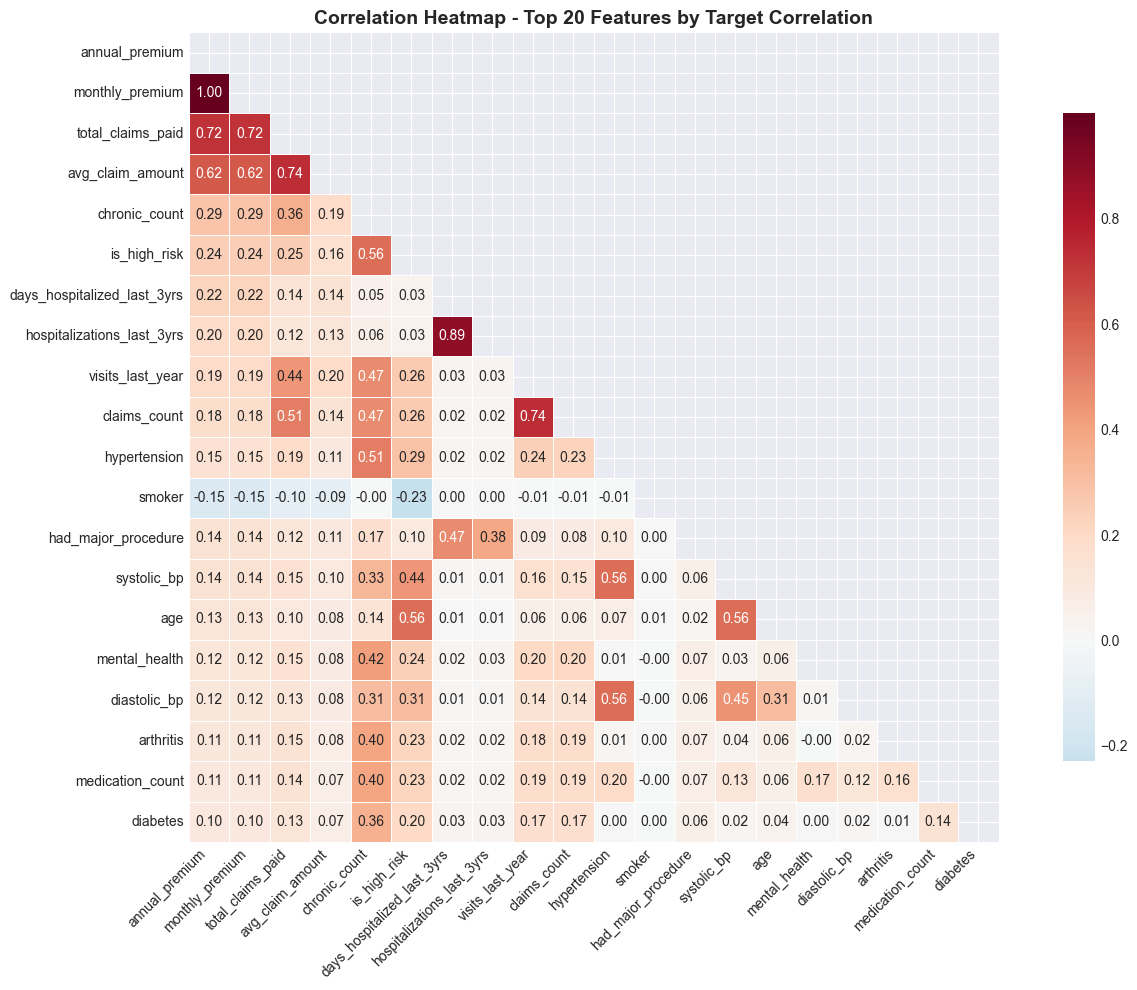


📌 LOW IMPORTANCE FEATURES (Bottom 20%, importance ≤ 0.0000):
   10 features identified
   • hypertension                   (importance: 0.0000)
   • plan_type                      (importance: 0.0000)
   • liver_disease                  (importance: 0.0000)
   • kidney_disease                 (importance: 0.0000)
   • cancer_history                 (importance: 0.0000)
   • cardiovascular_disease         (importance: 0.0000)
   • asthma                         (importance: 0.0000)
   • copd                           (importance: 0.0000)
   • mental_health                  (importance: 0.0000)
   • proc_lab_count                 (importance: 0.0000)

📌 FEATURES YOU COULD POTENTIALLY REMOVE (Low importance + Low correlation):
   • plan_type                      (importance: 0.0000, correlation: 0.0039)
   • liver_disease                  (importance: 0.0000, correlation: 0.0517)
   • kidney_disease                 (importance: 0.0000, correlation: 0.0439)
   • cancer_history            

In [101]:
#=============== FEATURE IMPORTANCE ANALYSIS ===============

# 1. Get feature importances from the trained model
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

# 2. Display top features
print("\n📊 TOP 20 MOST IMPORTANT FEATURES:")
print("-"*50)
for i, row in feature_importance.head(20).iterrows():
    print(f"{i+1:2d}. {row['feature']:30s} : {row['importance']:.4f} ({row['importance']*100:.2f}%)")

# 3. Show bottom features (can potentially remove)
print("\n📊 BOTTOM 10 FEATURES (Lowest Impact):")
print("-"*50)
for i, row in feature_importance.tail(10).iterrows():
    print(f"{row['feature']:30s} : {row['importance']:.4f} ({row['importance']*100:.4f}%)")

# 4. Calculate cumulative importance
feature_importance['cumulative_importance'] = feature_importance['importance'].cumsum()
print("\n📊 CUMULATIVE IMPORTANCE:")
print("-"*50)
print(f"Top 5 features account for: {feature_importance.iloc[:5]['importance'].sum()*100:.2f}% of predictive power")
print(f"Top 10 features account for: {feature_importance.iloc[:10]['importance'].sum()*100:.2f}%")
print(f"Top 20 features account for: {feature_importance.iloc[:20]['importance'].sum()*100:.2f}%")

# ================== VISUALIZATIONS ==================

# Create a comprehensive figure with 4 feature importance plots
fig = plt.figure(figsize=(20, 12))
fig.suptitle('Gradient Boosting Regressor - Feature Importance Analysis', 
             fontsize=16, fontweight='bold')

# Plot 1: Top 20 Features Bar Chart
ax1 = plt.subplot(2, 2, 1)
top_features = feature_importance.head(20)
colors = plt.cm.viridis(np.linspace(0, 1, 20))
bars = ax1.barh(range(len(top_features)), top_features['importance'].values, color=colors)
ax1.set_yticks(range(len(top_features)))
ax1.set_yticklabels(top_features['feature'].values)
ax1.set_xlabel('Importance Score', fontsize=12)
ax1.set_title('Top 20 Most Important Features', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_features['importance'].values)):
    ax1.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{val:.4f}', va='center', fontsize=9)
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: Cumulative Importance
ax2 = plt.subplot(2, 2, 2)
n_features = len(feature_importance)
ax2.plot(range(1, n_features + 1), feature_importance['cumulative_importance'].values, 
         'b-', linewidth=2.5, marker='o', markersize=4)
ax2.axhline(y=0.8, color='r', linestyle='--', label='80% Threshold', linewidth=2)
ax2.axhline(y=0.9, color='g', linestyle='--', label='90% Threshold', linewidth=2)
ax2.fill_between(range(1, n_features + 1), 0, feature_importance['cumulative_importance'].values, 
                  alpha=0.3, color='blue')
ax2.set_xlabel('Number of Features', fontsize=12)
ax2.set_ylabel('Cumulative Importance', fontsize=12)
ax2.set_title('Cumulative Feature Importance\n(How many features needed for 80%/90%?)', 
              fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Find how many features needed for 80% and 90%
n_80 = (feature_importance['cumulative_importance'] <= 0.8).sum() + 1
n_90 = (feature_importance['cumulative_importance'] <= 0.9).sum() + 1
ax2.axvline(x=n_80, color='r', linestyle=':', alpha=0.7)
ax2.axvline(x=n_90, color='g', linestyle=':', alpha=0.7)
ax2.text(n_80, 0.85, f' {n_80} features\n for 80%', ha='left', fontsize=10, color='red')
ax2.text(n_90, 0.75, f' {n_90} features\n for 90%', ha='left', fontsize=10, color='green')

# Plot 3: Feature Importance Distribution (Histogram)
ax3 = plt.subplot(2, 2, 3)
ax3.hist(feature_importance['importance'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax3.axvline(x=feature_importance['importance'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {feature_importance["importance"].mean():.4f}')
ax3.axvline(x=feature_importance['importance'].median(), color='orange', linestyle='--', 
            linewidth=2, label=f'Median: {feature_importance["importance"].median():.4f}')
ax3.set_xlabel('Importance Score', fontsize=12)
ax3.set_ylabel('Number of Features', fontsize=12)
ax3.set_title('Distribution of Feature Importance Scores\n(Most features have low importance)', 
              fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Top Features with Percentage
ax4 = plt.subplot(2, 2, 4)
top10 = feature_importance.head(10)
percentages = top10['importance'].values * 100
explode = [0.05] + [0] * 9  # Slightly explode the top feature
colors_pie = plt.cm.Set3(np.linspace(0, 1, 10))
wedges, texts, autotexts = ax4.pie(percentages, labels=top10['feature'].values, 
                                     autopct='%1.1f%%', explode=explode,
                                     colors=colors_pie, textprops={'fontsize': 9})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax4.set_title(f'Top 10 Features Contribution\n(Total: {percentages.sum():.1f}% of importance)', 
              fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


#=============== CORRELATION ANALYSIS WITH TARGET VARIABLE ===============

# Calculate correlation with target
correlations = []
for col in X_train.columns:
    corr = X_train[col].corr(y_train)
    correlations.append({
        'feature': col,
        'correlation_with_target': corr,
        'abs_correlation': abs(corr)
    })

corr_df = pd.DataFrame(correlations).sort_values('abs_correlation', ascending=False)

print("\n📊 TOP 15 FEATURES BY CORRELATION WITH MEDICAL COST:")
print("-"*60)
for i, row in corr_df.head(15).iterrows():
    direction = "Positive" if row['correlation_with_target'] > 0 else "Negative"
    strength = "Strong" if abs(row['correlation_with_target']) > 0.5 else "Moderate" if abs(row['correlation_with_target']) > 0.3 else "Weak"
    print(f"{row['feature']:30s} : {row['correlation_with_target']:7.4f} ({direction}, {strength})")

# Create correlation heatmap for top features
plt.figure(figsize=(14, 10))
top_corr_features = corr_df.head(20)['feature'].tolist()
correlation_matrix = X_train[top_corr_features].corr()

import seaborn as sns
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Top 20 Features by Target Correlation', 
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# =============== FEATURE SELECTION RECOMMENDATIONS ===============

# Identify low-importance features (bottom 20%)
threshold_low = feature_importance['importance'].quantile(0.20)
low_importance_features = feature_importance[feature_importance['importance'] <= threshold_low]['feature'].tolist()

print(f"\n📌 LOW IMPORTANCE FEATURES (Bottom 20%, importance ≤ {threshold_low:.4f}):")
print(f"   {len(low_importance_features)} features identified")
for feat in low_importance_features[:15]:  # Show first 15
    imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
    print(f"   • {feat:30s} (importance: {imp:.4f})")
if len(low_importance_features) > 15:
    print(f"   ... and {len(low_importance_features) - 15} more")

print("\n📌 FEATURES YOU COULD POTENTIALLY REMOVE (Low importance + Low correlation):")
candidates_for_removal = []
for feat in low_importance_features:
    corr_val = corr_df[corr_df['feature'] == feat]['abs_correlation'].values
    if len(corr_val) > 0 and corr_val[0] < 0.1:
        candidates_for_removal.append(feat)

for feat in candidates_for_removal[:10]:
    imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
    corr = corr_df[corr_df['feature'] == feat]['correlation_with_target'].values[0]
    print(f"   • {feat:30s} (importance: {imp:.4f}, correlation: {corr:.4f})")

# ================== SAVE RESULTS ==================

# Save feature importance to CSV
feature_importance.to_csv('feature_importance_results.csv', index=False)
corr_df.to_csv('feature_correlations.csv', index=False)



Final evaluation on unseen test set...

👾 Test Set Performance:
----------------------------------------
MAE  (Mean Absolute Error):     $34.94
MSE (Mean Squared Error): 13,122.47 (USD²)
RMSE (Root Mean Squared Error): $114.55
R² Score:                        0.9987
----------------------------------------

👾 Performance Comparison:
Validation R²: 0.9762
Test R²:       0.9987
Difference:    0.0224
✅ Test performance matches validation - Good generalization!


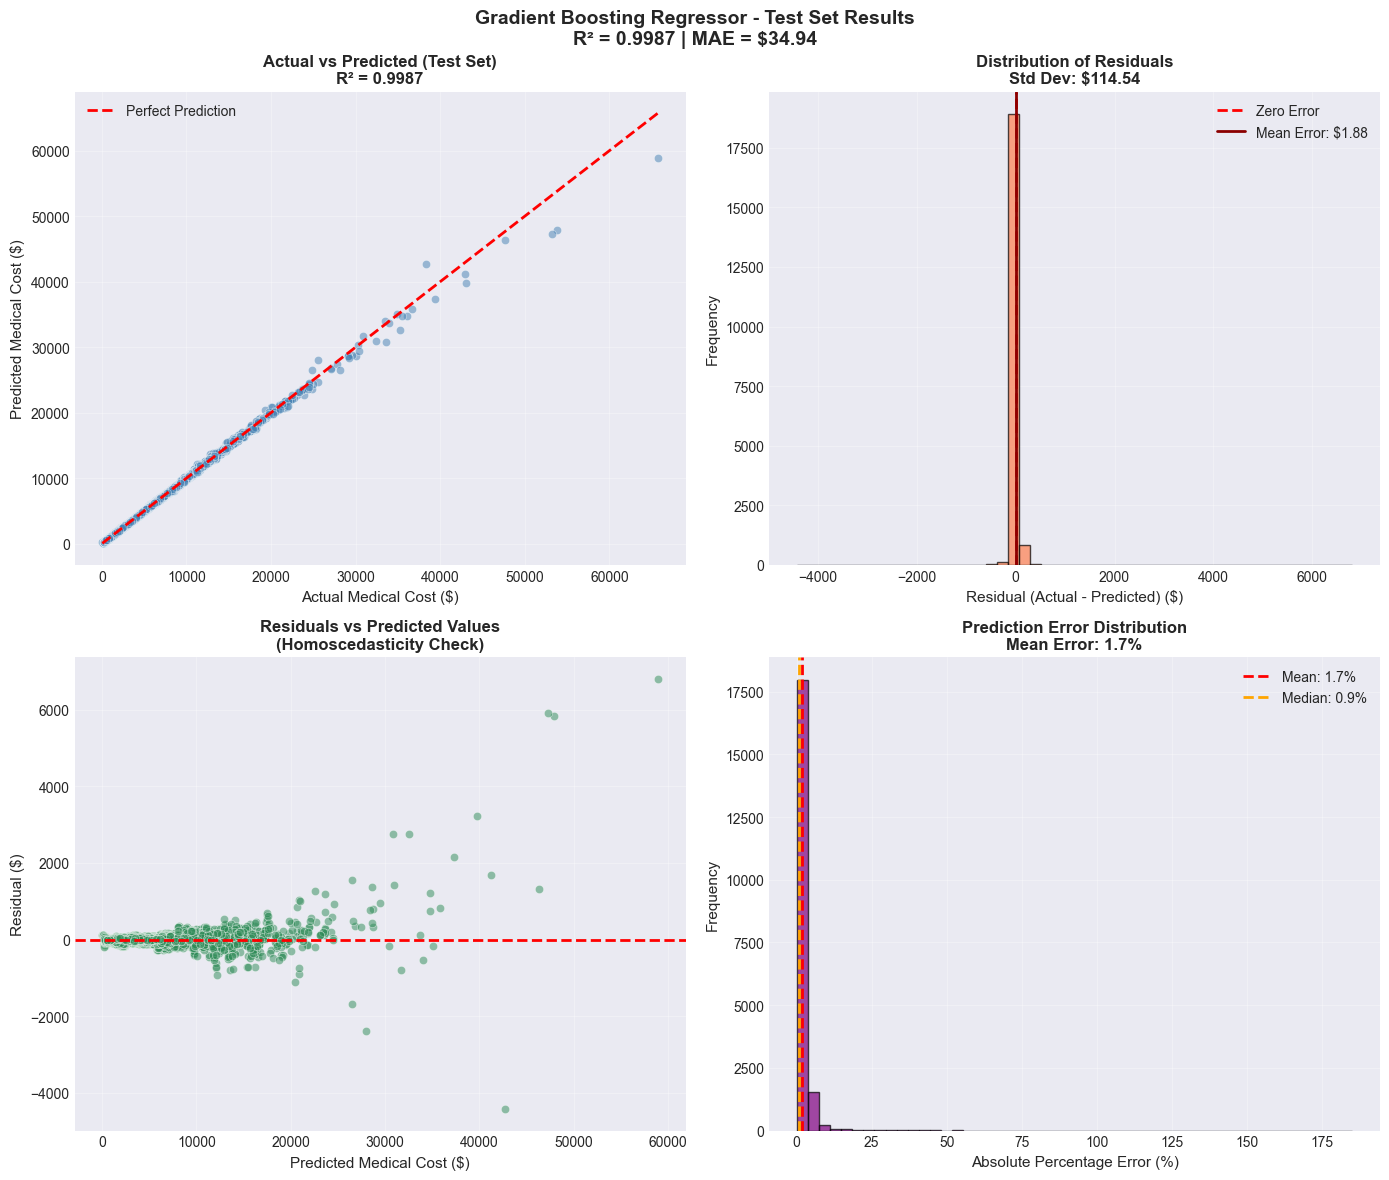

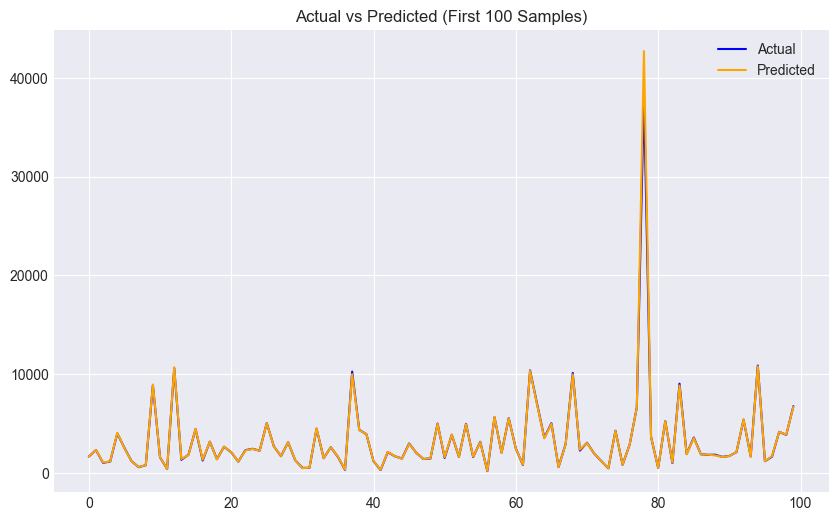

In [102]:
# 13. TEST ON UNSEEN TEST SET
print("\nFinal evaluation on unseen test set...")

# Make predictions on test set
y_test_pred = final_model.predict(X_test)

# Calculate test metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("\n👾 Test Set Performance:")
print("-"*40)
print(f"MAE  (Mean Absolute Error):     ${test_mae:,.2f}")
print(f"MSE (Mean Squared Error): {mse_test:,.2f} (USD²)")
print(f"RMSE (Root Mean Squared Error): ${test_rmse:,.2f}")
print(f"R² Score:                        {test_r2:.4f}")
print("-"*40)

# Compare with validation performance
print("\n👾 Performance Comparison:")
print(f"Validation R²: {val_r2_list[best_idx]:.4f}")
print(f"Test R²:       {test_r2:.4f}")
print(f"Difference:    {test_r2 - val_r2_list[best_idx]:.4f}")

if abs(test_r2 - val_r2_list[best_idx]) < 0.05:
    print("✅ Test performance matches validation - Good generalization!")
else:
    print("⚠️ Test performance differs from validation - Possible overfitting")

# 14. CREATE TEST SET VISUALIZATIONS
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(f'Gradient Boosting Regressor - Test Set Results\nR² = {test_r2:.4f} | MAE = ${test_mae:,.2f}', 
             fontsize=14, fontweight='bold')

# Plot 1: Actual vs Predicted
ax1 = axes[0, 0]
ax1.scatter(y_test, y_test_pred, alpha=0.5, c='steelblue', edgecolors='white', linewidth=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Medical Cost ($)', fontsize=11)
ax1.set_ylabel('Predicted Medical Cost ($)', fontsize=11)
ax1.set_title(f'Actual vs Predicted (Test Set)\nR² = {test_r2:.4f}', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals Distribution
ax2 = axes[0, 1]
residuals = y_test - y_test_pred
ax2.hist(residuals, bins=50, color='coral', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax2.axvline(x=residuals.mean(), color='darkred', linestyle='-', linewidth=2, 
           label=f'Mean Error: ${residuals.mean():.2f}')
ax2.set_xlabel('Residual (Actual - Predicted) ($)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title(f'Distribution of Residuals\nStd Dev: ${residuals.std():,.2f}', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Residuals vs Predicted
ax3 = axes[1, 0]
ax3.scatter(y_test_pred, residuals, alpha=0.5, c='seagreen', edgecolors='white', linewidth=0.5)
ax3.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Predicted Medical Cost ($)', fontsize=11)
ax3.set_ylabel('Residual ($)', fontsize=11)
ax3.set_title('Residuals vs Predicted Values\n(Homoscedasticity Check)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Percentage Error Distribution
ax4 = axes[1, 1]
percent_error = np.abs(residuals / y_test) * 100
percent_error = percent_error[percent_error < 200]  # Cap for visualization
ax4.hist(percent_error, bins=50, color='purple', edgecolor='black', alpha=0.7)
ax4.axvline(x=percent_error.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {percent_error.mean():.1f}%')
ax4.axvline(x=percent_error.median(), color='orange', linestyle='--', linewidth=2, 
           label=f'Median: {percent_error.median():.1f}%')
ax4.set_xlabel('Absolute Percentage Error (%)', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title(f'Prediction Error Distribution\nMean Error: {percent_error.mean():.1f}%', 
              fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('test_set_results.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10,6))

plt.plot(y_test.values[:100], label='Actual', color='blue')
plt.plot(y_test_pred[:100], label='Predicted', color='orange')

plt.title("Actual vs Predicted (First 100 Samples)")
plt.legend()

plt.show()

In [103]:
#15. DETAILED TEST RESULTS ANALYSIS
print("\nDetailed Test Results Analysis:")
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred,
})

results_df["Error"] = results_df["Actual"] - results_df["Predicted"]
results_df["Absolute_Error"] = np.abs(results_df["Error"])
results_df["% Error"] = (results_df["Absolute_Error"] / results_df["Actual"]) * 100

print("\n📊 Sample Test Results (First 20 rows):")
print(results_df.head(20))

print("\n📊 Random 20 Test Samples:")
print(results_df.sample(20, random_state=42))

print("\n📊 Test Results in Chunks (10 samples each):")

for i in range(0, 50, 10):  # first 50 rows, in groups of 10
    print(f"\n--- Samples {i} to {i+9} ---")
    print(results_df.iloc[i:i+10])

print("\n📊 Data used for 'First 100 Samples' Plot:")
print(results_df.head(100))

sample_100 = results_df.head(100)

print("\n📊 Stats for First 100 Samples:")
print("MAE:", sample_100["Absolute_Error"].mean())
print("RMSE:", np.sqrt(np.mean(sample_100["Error"]**2)))
print("R²:", r2_score(sample_100["Actual"], sample_100["Predicted"]))


Detailed Test Results Analysis:

📊 Sample Test Results (First 20 rows):
      Actual     Predicted      Error  Absolute_Error   % Error
0    1640.86   1635.030105   5.829895        5.829895  0.355295
1    2306.61   2316.627473 -10.017473       10.017473  0.434294
2    1015.03   1051.704055 -36.674055       36.674055  3.613101
3    1136.82   1152.707488 -15.887488       15.887488  1.397538
4    3990.84   4043.922090 -53.082090       53.082090  1.330098
5    2518.82   2488.923860  29.896140       29.896140  1.186911
6    1180.51   1174.682204   5.827796        5.827796  0.493668
7     571.16    589.670813 -18.510813       18.510813  3.240916
8     771.25    776.753367  -5.503367        5.503367  0.713565
9    8863.49   8937.916554 -74.426554       74.426554  0.839698
10   1572.16   1582.348835 -10.188835       10.188835  0.648079
11    396.99    405.011151  -8.021151        8.021151  2.020492
12  10595.20  10681.688162 -86.488162       86.488162  0.816296
13   1319.66   1397.436250 -77.